<a href="https://colab.research.google.com/github/princeiiitk/CampusX-ML/blob/main/HandleMissingValues/Handle_missingvalue_arbitrary_number.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!git clone 'https://github.com/princeiiitk/CampusX-ML'

Cloning into 'CampusX-ML'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 97 (delta 33), reused 35 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 1.35 MiB | 10.60 MiB/s, done.
Resolving deltas: 100% (33/33), done.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
df=pd.read_csv('/content/CampusX-ML/HandleMissingValues/titanic_toy (1).csv')
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [7]:
df.isnull().sum()

,0
Age,177
Fare,45
Family,0
Survived,0


In [8]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [9]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=20)


In [11]:
X_train['Age_99']=X_train['Age'].fillna(99)
X_train['Age_-1']=X_train['Age'].fillna(-1)
X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

In [12]:
print('original age variable variance',X_train['Age'].var())
print('new age variable variance',X_train['Age_99'].var())
print('new age variable variance',X_train['Age_-1'].var())
print('new Fare variable variance',X_train['Fare'].var())
print('new Fare variable variance',X_train['Fare_999'].var())
print('new Fare variable variance',X_train['Fare_minus1'].var())

original age variable variance 216.2807314806522
new age variable variance 945.1429710229457
new age variable variance 330.59117057586406
new Fare variable variance 2333.0507481149125
new Fare variable variance 54959.72899454162
new Fare variable variance 2252.934140471577


<Axes: ylabel='Density'>

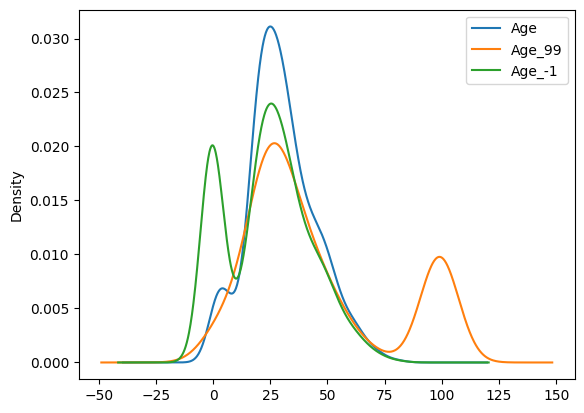

In [13]:
fig=plt.figure()
ax=fig.add_subplot()
# original variable distribution
X_train['Age'].plot(kind='kde',ax=ax,legend=True)
X_train['Age_99'].plot(kind='kde',ax=ax,legend=True)
X_train['Age_-1'].plot(kind='kde',ax=ax,legend=True)

<Axes: ylabel='Density'>

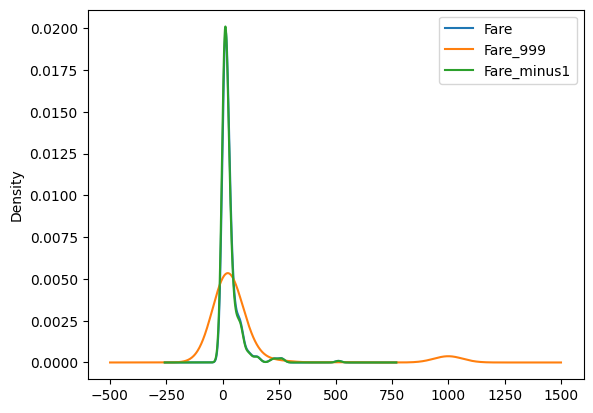

In [14]:
fig=plt.figure()
ax=fig.add_subplot()
# original variable distribution
X_train['Fare'].plot(kind='kde',ax=ax,legend=True)
X_train['Fare_999'].plot(kind='kde',ax=ax,legend=True)
X_train['Fare_minus1'].plot(kind='kde',ax=ax,legend=True)

In [15]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_-1,Fare_999,Fare_minus1
Age,1.000000,0.069051,-0.297584,1.000000,1.000000,0.027987,0.063753
Fare,0.069051,1.000000,0.216171,-0.060007,0.114681,1.000000,1.000000
Family,-0.297584,0.216171,1.000000,-0.138153,-0.144803,0.035806,0.211710
Age_99,1.000000,-0.060007,-0.138153,1.000000,-0.319324,-0.050421,-0.051483
Age_-1,1.000000,0.114681,-0.144803,-0.319324,1.000000,0.065923,0.103091
Fare_999,0.027987,1.000000,0.035806,-0.050421,0.065923,1.000000,0.037460
Fare_minus1,0.063753,1.000000,0.211710,-0.051483,0.103091,0.037460,1.000000


In [16]:
# using Sklearn
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=20)

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
imputer1=SimpleImputer(strategy='mean')
imputer2=SimpleImputer(strategy='median')
trf=ColumnTransformer([(
    'imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare']
)])

In [22]:
trf.fit(X_train)

ColumnTransformer(transformers=[('imputer1', SimpleImputer(), ['Age']),
                                ('imputer2', SimpleImputer(strategy='median'),
                                 ['Fare'])])

In [23]:
trf.named_transformers_['imputer1'].statistics_

array([30.18016949])

In [24]:
trf.named_transformers_['imputer2'].statistics_

array([14.4542])

In [25]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [26]:
X_train

array([[40.    , 27.7208],
       [ 3.    , 31.3875],
       [15.    ,  7.225 ],
       ...,
       [25.    , 14.4542],
       [22.    ,  9.8375],
       [28.    , 14.4542]])